In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.datasets import mnist

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


##  TensorFlow augmentation 7 methods

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)


# Model
def build_cnn(input_shape, num_classes, onehot=False):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    loss = "categorical_crossentropy" if onehot else "sparse_categorical_crossentropy"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=["accuracy"]
    )
    return model


# Common augmentation layers (create once)
rot = tf.keras.layers.RandomRotation(0.08)
trans = tf.keras.layers.RandomTranslation(0.08, 0.08)
zm = tf.keras.layers.RandomZoom(0.10)
con = tf.keras.layers.RandomContrast(0.10)


# 8 methods (0~7)
def method0(x, y):
    return x, y

def method1(x, y):
    x = rot(x, training=True)
    return x, y

def method2(x, y):
    x = trans(x, training=True)
    return x, y

def method3(x, y):
    x = zm(x, training=True)
    return x, y

def method4(x, y, is_rgb):
    x = rot(x, training=True)
    x = trans(x, training=True)
    x = zm(x, training=True)
    if is_rgb:
        x = con(x, training=True)
    return x, y

# Method 5: MixUp (one-hot y)
def method5(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    alpha = 0.2

    a = tf.random.gamma([batch_size], alpha)
    b = tf.random.gamma([batch_size], alpha)
    lam = a / (a + b + 1e-8)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * lam_x + x2 * (1.0 - lam_x)
    y = y * lam_y + y2 * (1.0 - lam_y)
    return x, y

# Method 6: CutMix (one-hot y, simple batch-wise)
def method6(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    height = tf.shape(x)[1]
    width = tf.shape(x)[2]
    channels = tf.shape(x)[3]

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    alpha = 1.0
    a = tf.random.gamma([], alpha)
    b = tf.random.gamma([], alpha)
    lam = a / (a + b + 1e-8)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(width, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(height, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, width, dtype=tf.int32)
    cy = tf.random.uniform([], 0, height, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, width)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, height)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, height)

    xs = tf.range(width)[None, :]
    ys = tf.range(height)[:, None]
    inside = tf.logical_and(
        tf.logical_and(xs >= x1, xs < x2b),
        tf.logical_and(ys >= y1, ys < y2b)
    )

    mask = tf.cast(inside, tf.float32)[None, ..., None]
    mask = tf.broadcast_to(mask, [batch_size, height, width, channels])

    x = x * (1.0 - mask) + x2 * mask

    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    lam_real = 1.0 - area / (tf.cast(height * width, tf.float32) + 1e-8)
    y = y * lam_real + y2 * (1.0 - lam_real)

    return x, y

# Method 7: RandAugment (built-in)
randaugment = tf.keras.layers.RandAugment(
    value_range=(0.0, 1.0),
    num_ops=2,
    factor=0.5
)

def method7(x, y, is_rgb):
    if not is_rgb:
        # 1-channel -> 3-channel
        x = tf.concat([x, x, x], axis=-1)

        # RandAugment needs 3 channels
        x = randaugment(x, training=True)

        # 3-channel -> 1-channel
        x = tf.reduce_mean(x, axis=-1, keepdims=True)
    else:
        x = randaugment(x, training=True)

    return x, y





# Train each method
def run_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    use_onehot = (method_id == 5 or method_id == 6)
    model = build_cnn(input_shape, num_classes, onehot=use_onehot)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    methods = [method0, method1, method2, method3, method4, method5, method6, method7]

    def train_map(x, y):
        for i in range(len(methods)):
            if i == method_id:
                if i == 4:
                    return methods[i](x, y, is_rgb)
                elif i in [5, 6]:
                    return methods[i](x, y, num_classes)
                elif i == 7:
                    return methods[i](x, y, is_rgb) 
                else:
                    return methods[i](x, y)


    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    if use_onehot:
        def val_map(x, y):
            y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y
        val_ds = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE)

    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc



# Plot
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## MNIST 



MNIST - Method 0
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.9494 - loss: 0.1671 - val_accuracy: 0.9806 - val_loss: 0.0639
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9842 - loss: 0.0503 - val_accuracy: 0.9804 - val_loss: 0.0572
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9887 - loss: 0.0356 - val_accuracy: 0.9868 - val_loss: 0.0434
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9889 - val_loss: 0.0339
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9841 - val_loss: 0.0544
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9945 - loss: 0.0165 - val_accuracy: 0.9885 - val_loss: 0.0347
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9964 - loss: 0.0114 - val_accuracy: 0.9883 - val_loss: 0.0409
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9963 - loss: 0.0108 - val_accuracy: 0.9899 - val_loss: 0.0357
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9972 - loss: 0.0086 - val_

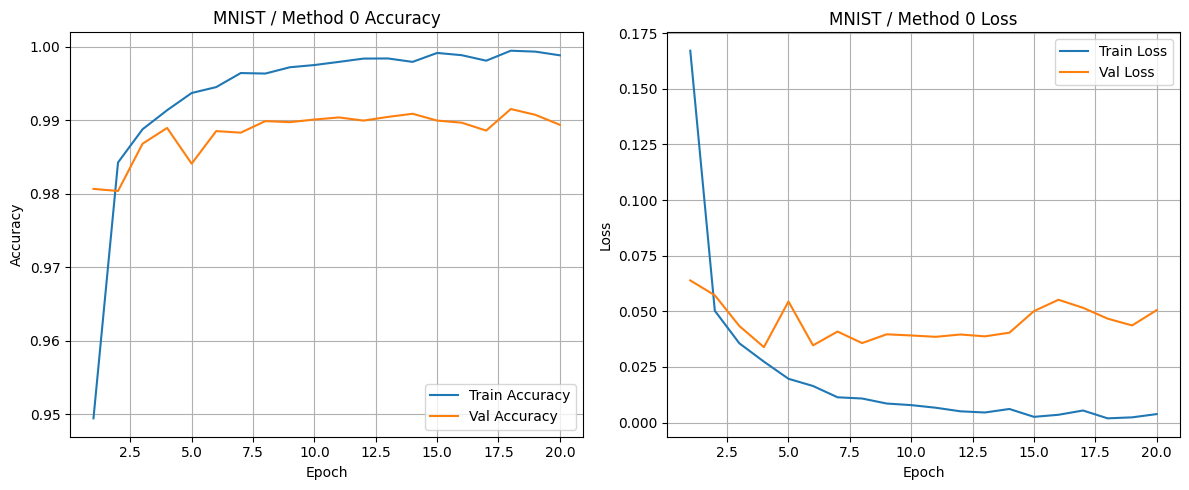



MNIST - Method 1
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.9316 - loss: 0.2222 - val_accuracy: 0.9770 - val_loss: 0.0732
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9757 - loss: 0.0786 - val_accuracy: 0.9837 - val_loss: 0.0516
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9815 - loss: 0.0589 - val_accuracy: 0.9850 - val_loss: 0.0433
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9851 - loss: 0.0483 - val_accuracy: 0.9842 - val_loss: 0.0481
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9871 - loss: 0.0417 - val_accuracy: 0.9881 - val_loss: 0.0406
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 0.9894 - val_loss: 0.0331
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9897 - loss: 0.0308 - val_accuracy: 0.9892 - val_loss: 0.0368
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9900 - loss: 0.0311 - val_accuracy: 0.9906 - val_loss: 0.0306
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9911 - loss: 0.0273 - val_

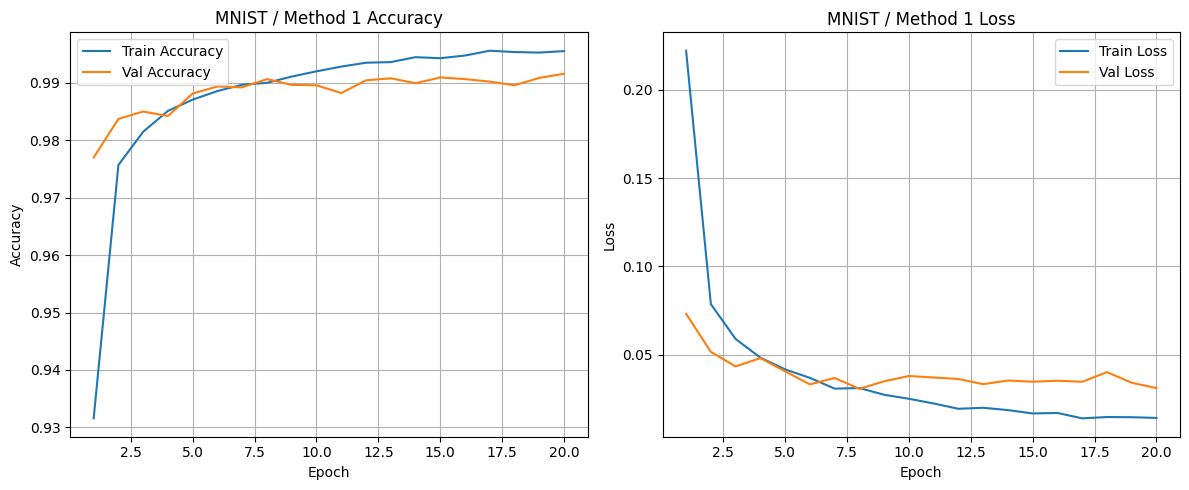



MNIST - Method 2
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.9210 - loss: 0.2528 - val_accuracy: 0.9801 - val_loss: 0.0628
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9739 - loss: 0.0856 - val_accuracy: 0.9832 - val_loss: 0.0546
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9797 - loss: 0.0648 - val_accuracy: 0.9886 - val_loss: 0.0333
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9848 - loss: 0.0498 - val_accuracy: 0.9866 - val_loss: 0.0454
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9869 - loss: 0.0426 - val_accuracy: 0.9897 - val_loss: 0.0352
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9879 - loss: 0.0383 - val_accuracy: 0.9916 - val_loss: 0.0279
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9893 - loss: 0.0337 - val_accuracy: 0.9901 - val_loss: 0.0298
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9904 - loss: 0.0308 - val_accuracy: 0.9924 - val_loss: 0.0248
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9909 - loss: 0.0277 - val_

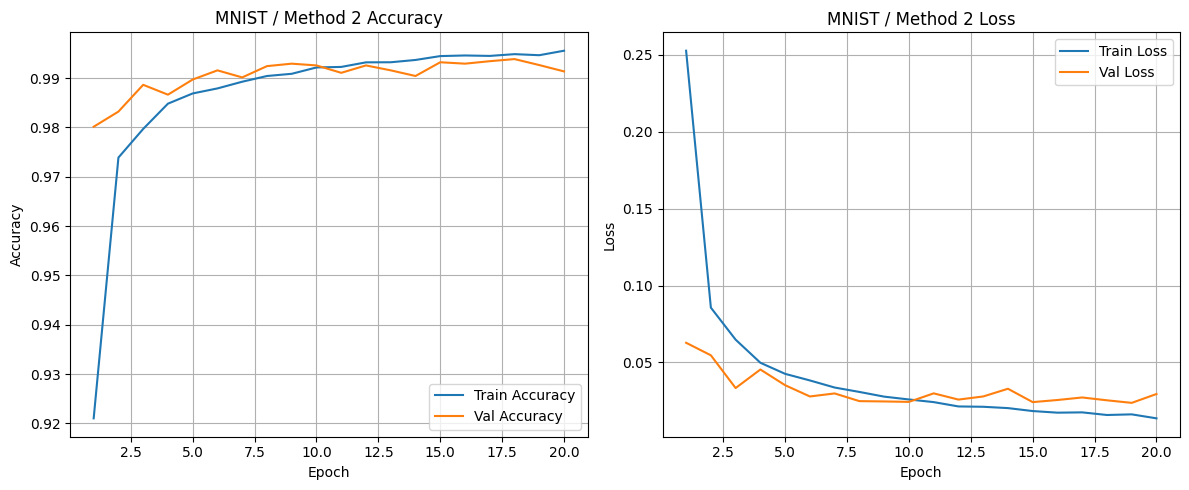



MNIST - Method 3
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.9498 - loss: 0.1703 - val_accuracy: 0.9790 - val_loss: 0.0654
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9831 - loss: 0.0528 - val_accuracy: 0.9844 - val_loss: 0.0468
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9887 - loss: 0.0377 - val_accuracy: 0.9849 - val_loss: 0.0475
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9892 - val_loss: 0.0366
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9926 - loss: 0.0227 - val_accuracy: 0.9886 - val_loss: 0.0409
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.9889 - val_loss: 0.0384
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9946 - loss: 0.0160 - val_accuracy: 0.9906 - val_loss: 0.0324
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9958 - loss: 0.0132 - val_accuracy: 0.9906 - val_loss: 0.0364
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9965 - loss: 0.0109 - val_

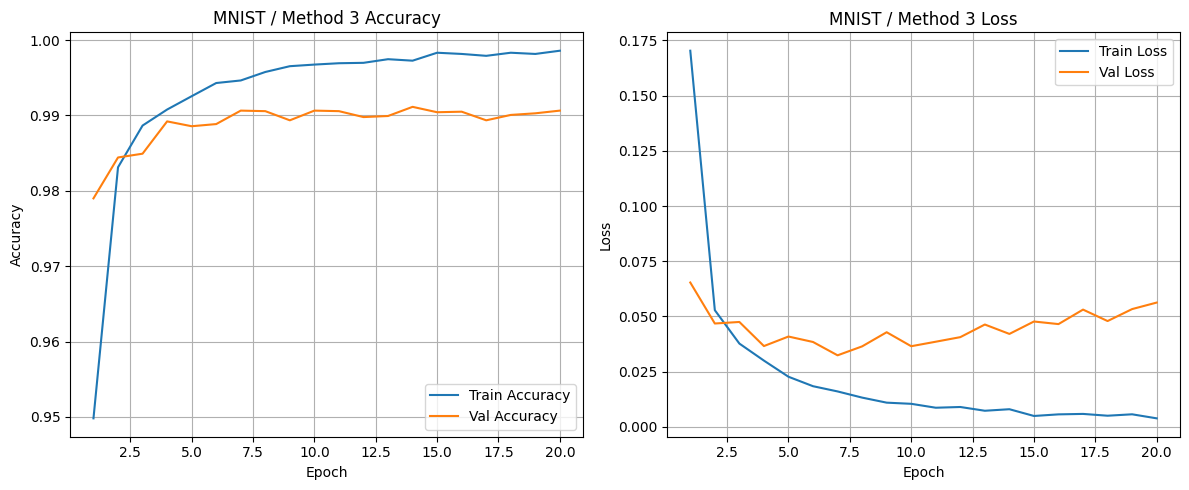



MNIST - Method 4
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.8743 - loss: 0.3947 - val_accuracy: 0.9725 - val_loss: 0.0915
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9563 - loss: 0.1402 - val_accuracy: 0.9812 - val_loss: 0.0605
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9681 - loss: 0.1036 - val_accuracy: 0.9867 - val_loss: 0.0444
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9747 - loss: 0.0813 - val_accuracy: 0.9852 - val_loss: 0.0517
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9785 - loss: 0.0698 - val_accuracy: 0.9852 - val_loss: 0.0502
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.9872 - val_loss: 0.0462
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9819 - loss: 0.0569 - val_accuracy: 0.9888 - val_loss: 0.0390
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9838 - loss: 0.0542 - val_accuracy: 0.9878 - val_loss: 0.0429
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9841 - loss: 0.0516 - val_

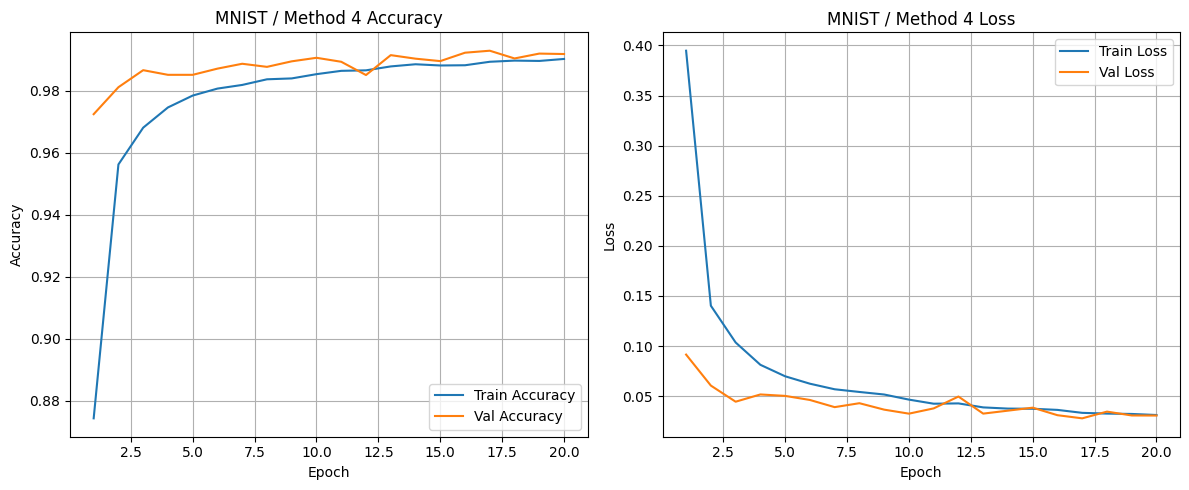



MNIST - Method 5
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.9210 - loss: 0.5419 - val_accuracy: 0.9794 - val_loss: 0.0925
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.9543 - loss: 0.4093 - val_accuracy: 0.9851 - val_loss: 0.0592
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.9523 - loss: 0.3747 - val_accuracy: 0.9869 - val_loss: 0.0542
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.9524 - loss: 0.3510 - val_accuracy: 0.9895 - val_loss: 0.0444
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.9538 - loss: 0.3336 - val_accuracy: 0.9898 - val_loss: 0.0425
Epoch 6/20
875/875 - 4s - 4ms/step - accuracy: 0.9548 - loss: 0.3211 - val_accuracy: 0.9911 - val_loss: 0.0403
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.9586 - loss: 0.3140 - val_accuracy: 0.9907 - val_loss: 0.0375
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.9577 - loss: 0.3073 - val_accuracy: 0.9917 - val_loss: 0.0330
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.9616 - loss: 0.2993 - val_

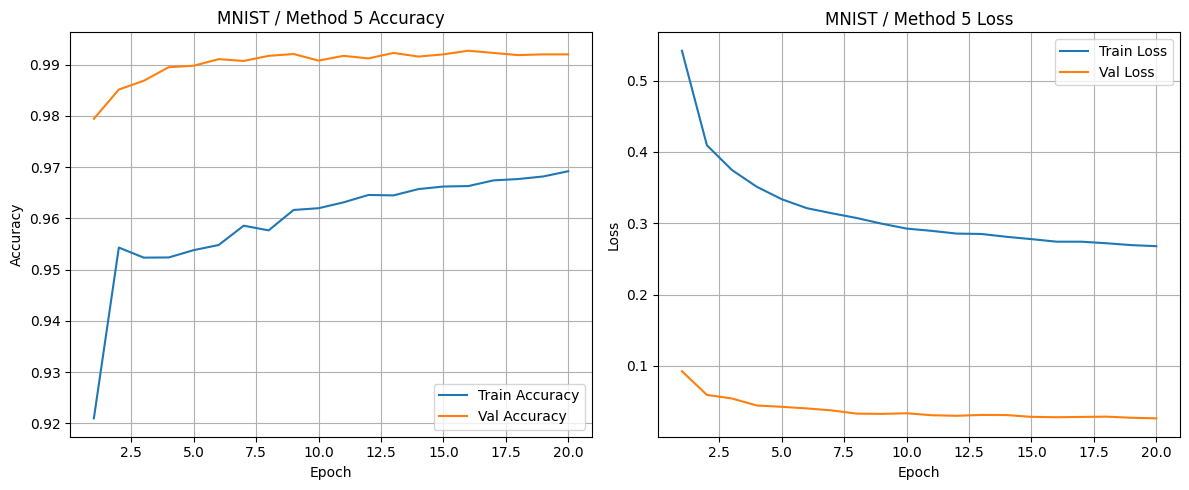



MNIST - Method 6
-----------------
Epoch 1/20
875/875 - 5s - 6ms/step - accuracy: 0.7289 - loss: 1.1850 - val_accuracy: 0.9692 - val_loss: 0.2194
Epoch 2/20
875/875 - 4s - 5ms/step - accuracy: 0.7758 - loss: 1.0542 - val_accuracy: 0.9738 - val_loss: 0.1910
Epoch 3/20
875/875 - 4s - 5ms/step - accuracy: 0.7864 - loss: 1.0088 - val_accuracy: 0.9801 - val_loss: 0.1671
Epoch 4/20
875/875 - 4s - 5ms/step - accuracy: 0.7940 - loss: 0.9825 - val_accuracy: 0.9818 - val_loss: 0.1600
Epoch 5/20
875/875 - 4s - 5ms/step - accuracy: 0.8004 - loss: 0.9632 - val_accuracy: 0.9841 - val_loss: 0.1506
Epoch 6/20
875/875 - 4s - 5ms/step - accuracy: 0.8024 - loss: 0.9469 - val_accuracy: 0.9846 - val_loss: 0.1476
Epoch 7/20
875/875 - 4s - 5ms/step - accuracy: 0.8023 - loss: 0.9412 - val_accuracy: 0.9845 - val_loss: 0.1384
Epoch 8/20
875/875 - 4s - 5ms/step - accuracy: 0.8039 - loss: 0.9308 - val_accuracy: 0.9851 - val_loss: 0.1403
Epoch 9/20
875/875 - 4s - 5ms/step - accuracy: 0.8078 - loss: 0.9216 - val_

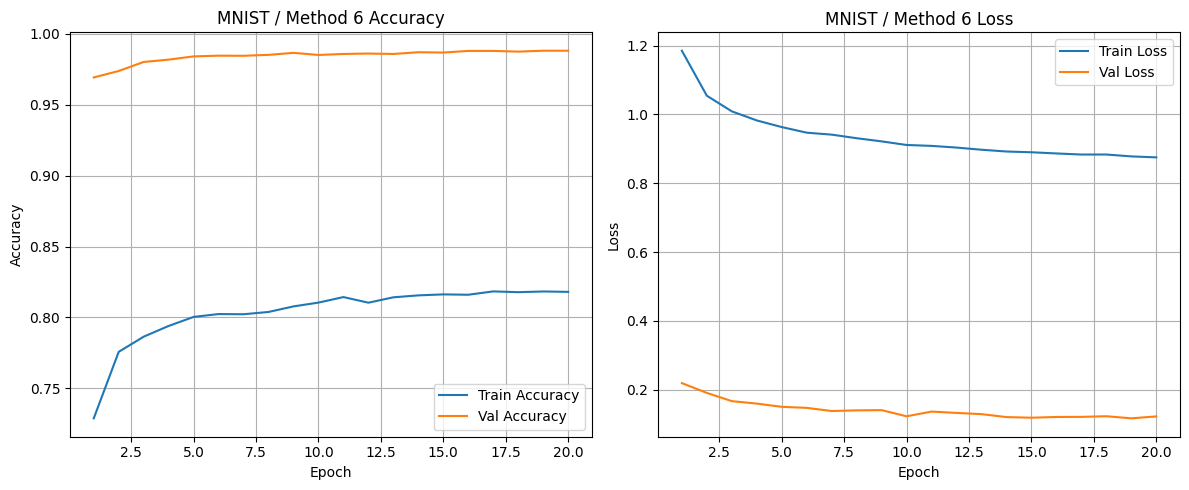



MNIST - Method 7
-----------------
Epoch 1/20
875/875 - 8s - 9ms/step - accuracy: 0.7029 - loss: 0.9555 - val_accuracy: 0.9631 - val_loss: 0.1263
Epoch 2/20
875/875 - 7s - 8ms/step - accuracy: 0.8141 - loss: 0.6061 - val_accuracy: 0.9613 - val_loss: 0.1211
Epoch 3/20
875/875 - 7s - 8ms/step - accuracy: 0.8573 - loss: 0.4708 - val_accuracy: 0.9746 - val_loss: 0.0844
Epoch 4/20
875/875 - 7s - 8ms/step - accuracy: 0.8708 - loss: 0.4254 - val_accuracy: 0.9794 - val_loss: 0.0679
Epoch 5/20
875/875 - 7s - 8ms/step - accuracy: 0.8862 - loss: 0.3705 - val_accuracy: 0.9779 - val_loss: 0.0727
Epoch 6/20
875/875 - 7s - 8ms/step - accuracy: 0.8845 - loss: 0.3746 - val_accuracy: 0.9853 - val_loss: 0.0510
Epoch 7/20
875/875 - 7s - 8ms/step - accuracy: 0.8988 - loss: 0.3277 - val_accuracy: 0.9862 - val_loss: 0.0479
Epoch 8/20
875/875 - 7s - 8ms/step - accuracy: 0.9030 - loss: 0.3138 - val_accuracy: 0.9827 - val_loss: 0.0603
Epoch 9/20
875/875 - 7s - 8ms/step - accuracy: 0.9004 - loss: 0.3217 - val_

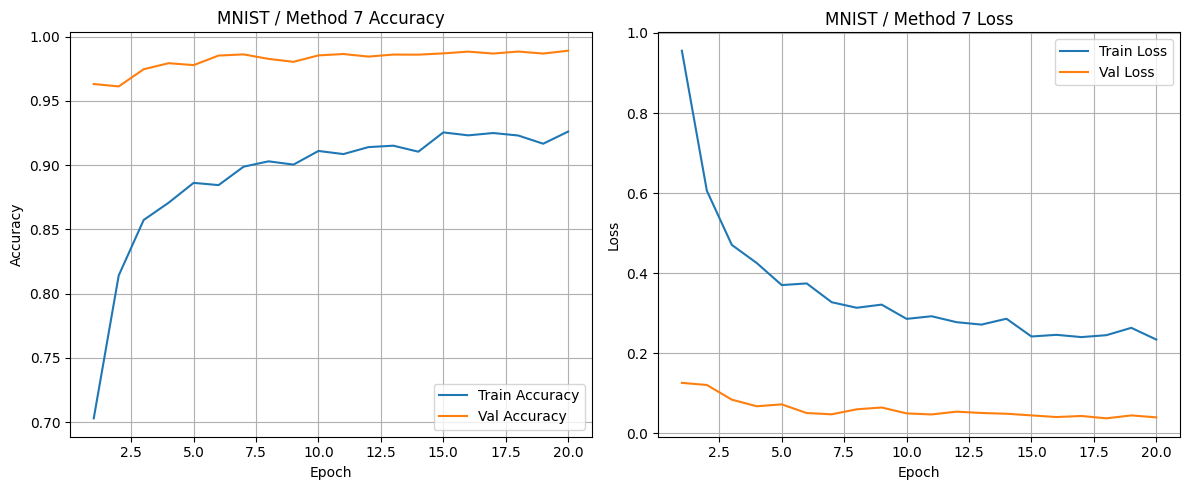


Final accuracy summary (MNIST):
Method 0: train_acc=0.9988, val_acc=0.9894
Method 1: train_acc=0.9955, val_acc=0.9916
Method 2: train_acc=0.9956, val_acc=0.9914
Method 3: train_acc=0.9986, val_acc=0.9906
Method 4: train_acc=0.9903, val_acc=0.9919
Method 5: train_acc=0.9692, val_acc=0.9920
Method 6: train_acc=0.8181, val_acc=0.9881
Method 7: train_acc=0.9261, val_acc=0.9891


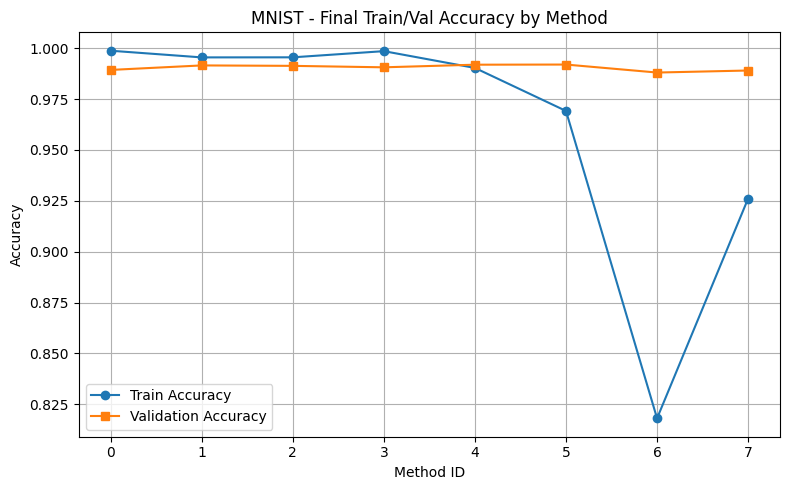

In [3]:
(X0, y0), (X1, y1) = mnist.load_data()
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

X = X.astype("float32") / 255.0

# (N, 28, 28, 1)
X = X[..., None]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (28, 28, 1)
num_classes = 10
is_rgb = False

results = {}

for method_id in range(8):
    print("\n")
    print(f"MNIST - Method {method_id}")
    print("-----------------")

    history, train_acc, val_acc = run_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape,
        num_classes=num_classes,
        method_id=method_id,
        is_rgb=is_rgb
    )

    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"MNIST / Method {method_id}")

print("\nFinal accuracy summary (MNIST):")
for k in range(8):
    ta, va = results[k]
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="MNIST - Final Train/Val Accuracy by Method")